Importing libraries

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report  # evaluate
import matplotlib.pyplot as plt
import random

# Step 1: Dataset preparation

In [3]:
data = [
    # Positive
    ("I love this movie, it was fantastic!", 1),
    ("Amazing plot and great performances!", 1),
    ("What a wonderful experience!", 1),
    ("Brilliant direction and strong cast.", 1),
    ("Absolutely loved it!", 1),
    ("A masterpiece of modern cinema.", 1),
    ("The visuals and story were breathtaking.", 1),
    ("Exceptional acting and brilliant screenplay.", 1),
    ("Truly inspiring and well-crafted.", 1),
    ("An emotional rollercoaster with a happy end.", 1),
    ("The movie exceeded my expectations.", 1),
    ("I enjoyed every minute of it.", 1),
    ("Heartwarming and deeply moving.", 1),
    ("A compelling story with great characters.", 1),
    ("The actors delivered fantastic performances.", 1),
    ("An unforgettable experience.", 1),
    ("The direction was top-notch.", 1),
    ("Highly entertaining and beautifully shot.", 1),
    ("Best movie I've seen this year!", 1),
    ("Wonderful execution and pacing.", 1),
    ("Left me speechless, in a good way.", 1),
    ("Incredible storytelling and visuals.", 1),
    ("Uplifting and inspiring movie.", 1),
    ("A joy to watch from start to finish.", 1),
    ("Loved the soundtrack and cinematography.", 1),
    ("Totally worth watching again!", 1),
    ("The dialogue was witty and smart.", 1),
    ("Very touching and well-acted.", 1),
    ("The characters felt very real and human.", 1),
    ("A fresh and original take on a familiar genre.", 1),
    ("The chemistry between the leads was amazing.", 1),
    ("Impressive production quality and plot depth.", 1),
    ("Simply stunning and emotionally satisfying.", 1),
    ("Loved the twists and turns.", 1),
    ("This film deserves all the praise.", 1),
    ("I was completely immersed.", 1),
    ("It was okay, not the best but enjoyable.", 1),
    ("Pleasantly surprised by how good it was.", 1),
    ("A solid movie night pick.", 1),
    ("Engaging and thoughtful throughout.", 1),
    ("I smiled through most of the film.", 1),
    ("Definitely recommend this movie.", 1),
    ("A positive and feel-good story.", 1),
    ("An all-time favorite!", 1),
    ("Five stars from me!", 1),
    ("A nice blend of humor and emotion.", 1),
    ("Very entertaining.", 1),
    ("One of the better films this year.", 1),
    ("Charming and full of heart.", 1),
    ("Didn't expect to love it this much.", 1),

    # Negative
    ("Absolutely terrible. Waste of time.", 0),
    ("Worst acting I have ever seen.", 0),
    ("I didn't like it at all.", 0),
    ("The film was boring and predictable.", 0),
    ("Horrible. I walked out halfway.", 0),
    ("A complete disaster from start to finish.", 0),
    ("Terribly written and poorly executed.", 0),
    ("The plot made no sense.", 0),
    ("A mess of clichés and bad dialogue.", 0),
    ("Not worth the hype.", 0),
    ("It was painful to sit through.", 0),
    ("The pacing was way off.", 0),
    ("Characters were flat and uninteresting.", 0),
    ("Too many plot holes to count.", 0),
    ("Acting was wooden and emotionless.", 0),
    ("An insult to the genre.", 0),
    ("Predictable and lazy writing.", 0),
    ("Music was distracting and out of place.", 0),
    ("Uninspired and forgettable.", 0),
    ("Dialogue felt forced and unnatural.", 0),
    ("It dragged on forever.", 0),
    ("Couldn’t connect with any character.", 0),
    ("The trailer was better than the movie.", 0),
    ("Disappointing and dull.", 0),
    ("Felt like a waste of money.", 0),
    ("The jokes were cringe-worthy.", 0),
    ("It lacked depth and originality.", 0),
    ("Too predictable and not funny.", 0),
    ("Very slow and uninteresting plot.", 0),
    ("Nothing happened for an hour.", 0),
    ("Really bad camera work and sound.", 0),
    ("The ending was abrupt and made no sense.", 0),
    ("Failed to deliver any emotion.", 0),
    ("Overacted and overhyped.", 0),
    ("Not even good for background noise.", 0),
    ("Terribly boring.", 0),
    ("I regret watching it.", 0),
    ("Very disappointing.", 0),
    ("One of the worst films I've seen.", 0),
    ("Unbelievably bad.", 0),
    ("A total flop.", 0),
    ("The cast seemed confused.", 0),
    ("The story didn’t go anywhere.", 0),
    ("I almost fell asleep.", 0),
    ("Nothing redeeming about it.", 0),
    ("It tried too hard to be deep.", 0),
    ("Just plain bad.", 0),
    ("I wanted to leave early.", 0),
    ("Bad acting, worse writing.", 0),
    ("Complete waste of time.", 0),
]


In [4]:
type(data)

list

In [5]:
len(data)

100

# Tokenization:
- split text to tokens
- vocabulary assigns each word an unique ID. (This will help turn the text to a list of numbers)

In [24]:
random.shuffle(data)

def tokenize(text):
  return text.lower().replace('.', '').replace(',','').split()


vocab = {"<PAD>":0, "<UNK>":1}
for text, _ in data:
  for token in tokenize(text):
    if token not in vocab:
      vocab[token]= len(vocab)

### Encode:


In [25]:
def encode(text, max_len = 10):
  tokens = tokenize(text)
  ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
  ids = ids[:max_len] + [vocab["<PAD>"]] * (max_len - len(ids))
  return torch.tensor(ids)

## Class

In [26]:
class SentimentDataset(Dataset):
  def __init__(self, data):
    self.samples = data

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    text, label = self.samples[idx]
    return encode(text), torch.tensor(label)

Split:

In [27]:
train_data = data[:80]
len(train_data)

80

In [28]:
test_data = data[80:]

In [29]:
len(test_data)

20

### Dataloader

In [30]:
train_loader = DataLoader(SentimentDataset(train_data), batch_size=2, shuffle=True)
test_loader = DataLoader(SentimentDataset(test_data), batch_size=2, shuffle=True)

In [31]:
len(train_loader)

40

# Step 2: Model Building:

 - embedding: word---> dense vector
  - instead of one-hot encoding, which is very sparse, we use **trainable** dense vectors to represent the words/text (in a continuous space)
  - vocab_size = number of words in vocabulary
  - embed_dim = size of each word vector (for example: 256)


In [32]:
class SimpleSentimentModel(nn.Module):
  def __init__(self, vocab_size, embed_dim=16, hidden_dim=8):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    self.fc1 = nn.Linear(embed_dim, hidden_dim)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim, 2)

  def forward(self,x):
    embedded = self.embedding(x)
    pooled = embedded.mean(dim=1)
    out = self.relu(self.fc1(pooled))
    return self.fc2(out)

(model)object instantiation

In [33]:
model = SimpleSentimentModel(vocab_size = len(vocab)).to(torch.device("cpu"))

In [34]:
model

SimpleSentimentModel(
  (embedding): Embedding(275, 16, padding_idx=0)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=2, bias=True)
)

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# Step 3: Training loop

In [36]:
num_epochs = 20
loss_values = []
accuracy_values = []

for epoch in range(num_epochs):
  model.train()
  total_loss = 0
  all_preds, all_labels = [], []

  for texts, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(texts)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    preds = torch.argmax(outputs, dim=1)
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())

  avg_loss = total_loss / len(train_loader)
  accuracy = accuracy_score(all_labels, all_preds)

  loss_values.append(avg_loss)
  accuracy_values.append(accuracy)

  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/20, Loss: 0.7168, Accuracy: 0.4750
Epoch 2/20, Loss: 0.7058, Accuracy: 0.4750
Epoch 3/20, Loss: 0.6958, Accuracy: 0.4750
Epoch 4/20, Loss: 0.6859, Accuracy: 0.5125
Epoch 5/20, Loss: 0.6775, Accuracy: 0.5875
Epoch 6/20, Loss: 0.6655, Accuracy: 0.6250
Epoch 7/20, Loss: 0.6556, Accuracy: 0.6375
Epoch 8/20, Loss: 0.6415, Accuracy: 0.7500
Epoch 9/20, Loss: 0.6276, Accuracy: 0.8000
Epoch 10/20, Loss: 0.6115, Accuracy: 0.7875
Epoch 11/20, Loss: 0.5937, Accuracy: 0.8250
Epoch 12/20, Loss: 0.5742, Accuracy: 0.8375
Epoch 13/20, Loss: 0.5542, Accuracy: 0.8375
Epoch 14/20, Loss: 0.5298, Accuracy: 0.8750
Epoch 15/20, Loss: 0.5039, Accuracy: 0.8750
Epoch 16/20, Loss: 0.4758, Accuracy: 0.8875
Epoch 17/20, Loss: 0.4473, Accuracy: 0.8875
Epoch 18/20, Loss: 0.4164, Accuracy: 0.9125
Epoch 19/20, Loss: 0.3855, Accuracy: 0.9375
Epoch 20/20, Loss: 0.3556, Accuracy: 0.9375


### Plot

<function matplotlib.pyplot.show(close=None, block=None)>

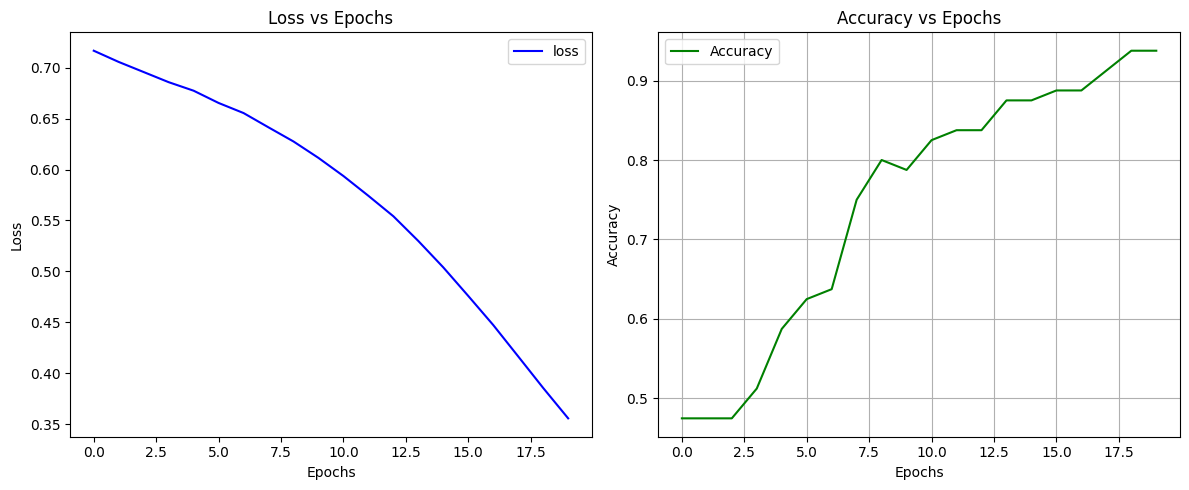

In [40]:
plt.figure(figsize = (12,5))

# subplot for loss
plt.subplot(1,2,1)
plt.plot(loss_values, label = "loss", color = 'blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

# subplot for accuracy
plt.subplot(1,2,2)
plt.plot(accuracy_values, label = "Accuracy", color = 'green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show

# Evaluation:

In [41]:
model.eval()   # droput, batch_norm not done
all_preds, all_labels = [], []

with torch.no_grad():    # no gradient calculation
  for texts, labels in test_loader:
    outputs = model(texts)
    preds = torch.argmax(outputs, dim=1)
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names = ["Negative", "Positives"]))

Accuracy: 0.6
              precision    recall  f1-score   support

    Negative       0.50      0.88      0.64         8
   Positives       0.83      0.42      0.56        12

    accuracy                           0.60        20
   macro avg       0.67      0.65      0.60        20
weighted avg       0.70      0.60      0.59        20



In [53]:
class SimpleSentimentModel2(nn.Module):
  def __init__(self, vocab_size, embed_dim=16, hidden_dim=8):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    self.fc1 = nn.Linear(embed_dim, hidden_dim)  # Original: embed_dim, hidden_dim
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim, 2)

  def forward(self,x):
    embedded = self.embedding(x)
    # Calculate mean over the embedding dimension (1) to get a fixed-size representation
    pooled = embedded.mean(dim=0) # Changed from dim=1 to dim=0

    # pooled shape is now (embed_dim,) which is (16,)
    out = self.relu(self.fc1(pooled)) # Input for fc1 should be (batch_size, embed_dim)

    # Now 'out' shape is (hidden_dim,) which is (8,)
    return self.fc2(out) # Input for fc2 should be (batch_size, hidden_dim)

In [54]:
model2 = SimpleSentimentModel2(vocab_size = len(vocab))

In [60]:
text_sample = "The movie was really bad"
# Encode the text sample using the 'encode' function
encoded_sample = encode(text_sample)
output_sample = model2(encoded_sample) # Pass the encoded sample to the model

In [61]:
print(output_sample)

tensor([-0.0549,  0.3098], grad_fn=<ViewBackward0>)


In [62]:
sample_preds = torch.argmax(output_sample, dim=0)
sample_preds

tensor(1)